# Effects of Alcohol on Student Performance.
## A Study of Stellenbosch University Students.

#### About Dataset
#### Aim:
The main aim of this project is to predict students academic performance (grades) using a multilinear regression model built on the predictors mentioned based on 2023 student information.

![alt text](1.jpg)

![alt text](2.jpg)

![alt text](3.jpg)

*Monthly_allowance are amounts are in rands

___

In [2]:
import matplotlib as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
columns_headers = [
    "time", "gender", "highschool_%", "study_year","faculty","unv_grade_2023","accomodation","allowance","scholarship","study_hours",
    "party_week","drinks_night","missed_classes", "failed_classes", "in_relationship","parent_approve","relation_parent"
]
df = pd.read_csv("Stats_survey.csv", names=columns_headers, header=0)

___
# EDA PART
___

In [4]:
df.shape

(406, 17)

The given dataset has 406 rows and 17 column respectively. It denotes 406 students data.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             406 non-null    str    
 1   gender           404 non-null    str    
 2   highschool_%     399 non-null    float64
 3   study_year       333 non-null    str    
 4   faculty          399 non-null    str    
 5   unv_grade_2023   320 non-null    float64
 6   accomodation     383 non-null    str    
 7   allowance        375 non-null    str    
 8   scholarship      398 non-null    str    
 9   study_hours      403 non-null    str    
 10  party_week       404 non-null    str    
 11  drinks_night     404 non-null    str    
 12  missed_classes   403 non-null    str    
 13  failed_classes   403 non-null    str    
 14  in_relationship  403 non-null    str    
 15  parent_approve   402 non-null    str    
 16  relation_parent  403 non-null    str    
dtypes: float64(2), str(15)
memo

For the given dataset having 406 rows and 17 column, except for the time every other column has a null value.

Only two column has numeric data. Here multiple other column could also be changed to numeric data for further analysis.

In [6]:
df.drop(columns = "time", inplace = True)

In [7]:
df.describe()

,highschool_%,unv_grade_2023
count,399.000000,320.000000
mean,77.989724,66.268469
std,7.048618,9.147906
min,34.000000,30.000000
25%,74.000000,60.000000
50%,78.000000,65.000000
75%,83.000000,73.000000
max,99.000000,95.220000


For the given non-null values, highschool percentage has a mean of 77 % and a standard deviation of ~7 where as the academic average in 2023 has mean of 66 % and standard deviation of ~9.

___

In [8]:
df.describe(include = "object")

C:\Users\bobs9\AppData\Local\Temp\ipykernel_21408\3591357663.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = "object")


,gender,study_year,faculty,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
count,404,333,399,383,375,398,403,404,404,403,403,403,402,403
unique,2,5,8,2,5,2,5,6,5,5,5,2,2,4
top,Male,2nd Year,Economic & Management Sciences,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,5-8,0,0,No,Yes,Very close
freq,216,153,211,335,159,352,114,113,111,214,263,239,353,269


___

In [9]:
df.head()

,gender,highschool_%,study_year,faculty,unv_grade_2023,accomodation,allowance,scholarship,study_hours,party_week,drinks_night,missed_classes,failed_classes,in_relationship,parent_approve,relation_parent
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [10]:
df.duplicated().sum()

np.int64(3)

There is three row with duplicated values.

In [11]:
df.isna().sum()

gender              2
highschool_%        7
study_year         73
faculty             7
unv_grade_2023     86
accomodation       23
allowance          31
scholarship         8
study_hours         3
party_week          2
drinks_night        2
missed_classes      3
failed_classes      3
in_relationship     3
parent_approve      4
relation_parent     3
dtype: int64

For the given dataset, the number of null per column is low on average while study_year ,ung_grade_2023, accomodation, allowance has 73,86,23, and 31 null values respectively.

In [12]:
corr = df.corr(numeric_only= True)
corr

,highschool_%,unv_grade_2023
highschool_%,1.000000,0.299104
unv_grade_2023,0.299104,1.000000


The correlation between highschool percentage and on going year average grade has weak positive correlation.

___
# Data visualization
___

<Axes: xlabel='gender'>

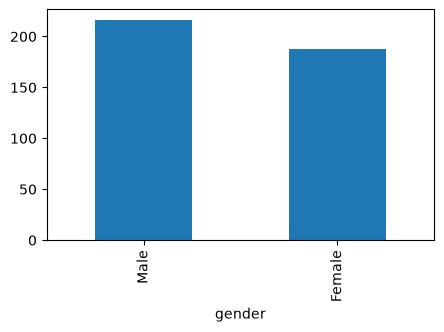

In [13]:
df.gender.value_counts().plot(kind = "bar", figsize= (5,3))

The number of male students who took part in survey is greater than that of female students.

<Axes: >

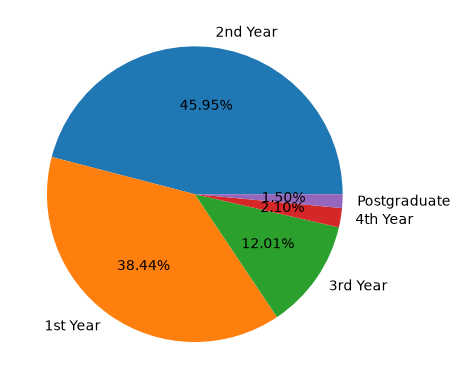

In [14]:
df.study_year.value_counts().plot(kind = "pie", autopct = "%1.2f%%")

Larger portion of students who took part in the survey is from 1st and 2nd year.

<Axes: >

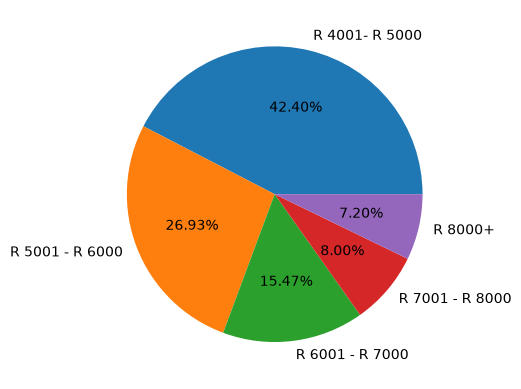

In [15]:
df.allowance.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

<Axes: >

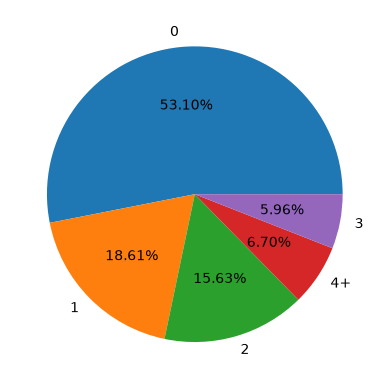

In [16]:
df.missed_classes.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

<Axes: >

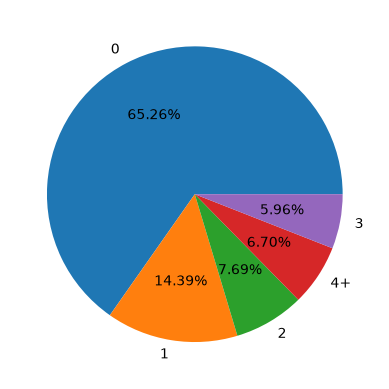

In [17]:
df.failed_classes.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

The larger portion of allowance allocated to the students are in range of 4001 to 5000 and 5001 to 6000 rands.

<Axes: ylabel='faculty'>

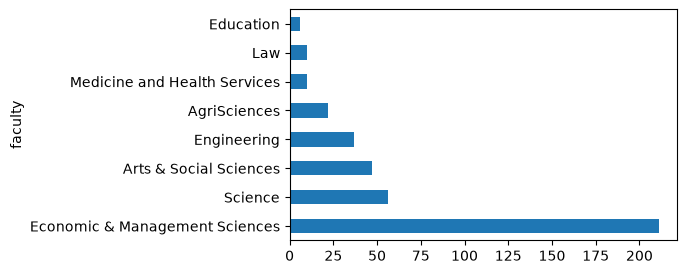

In [18]:
df.faculty.value_counts().plot(kind = "barh", figsize= (5,3))

Huge amount of students who took the survey are from " Economic and Management Sciences"

<Axes: ylabel='accomodation'>

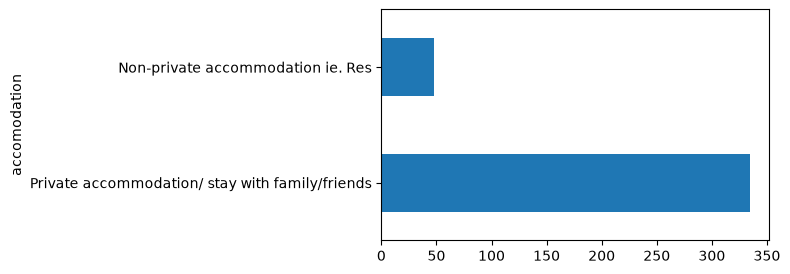

In [19]:
df.accomodation.value_counts().plot(kind = "barh", figsize= (5,3))

Most students either has private accomodation or stay with friends or family.

<Axes: xlabel='scholarship'>

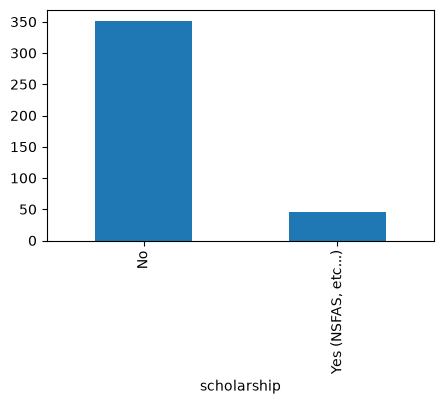

In [20]:
df.scholarship.value_counts().plot(kind = "bar", figsize= (5,3))

Only a few number of students have scholorship.

<Axes: >

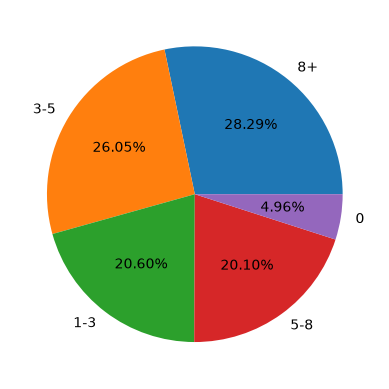

In [21]:
df.study_hours.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

<Axes: >

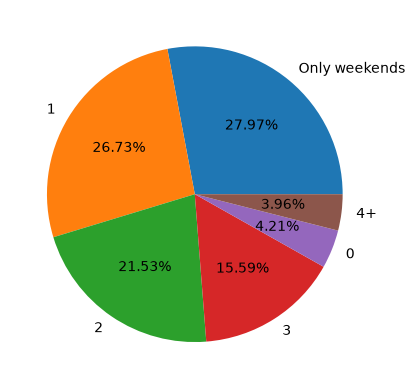

In [22]:
df.party_week.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

<Axes: >

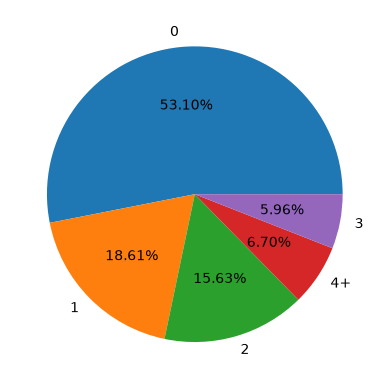

In [23]:
df.missed_classes.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

<Axes: >

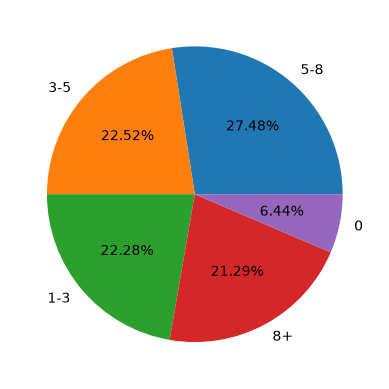

In [24]:
df.drinks_night.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

<Axes: xlabel='in_relationship'>

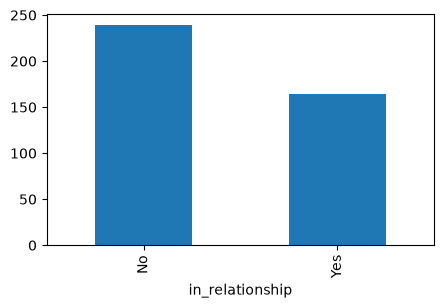

In [25]:
df.in_relationship.value_counts().plot(kind = "bar", figsize= (5,3))

<Axes: xlabel='parent_approve'>

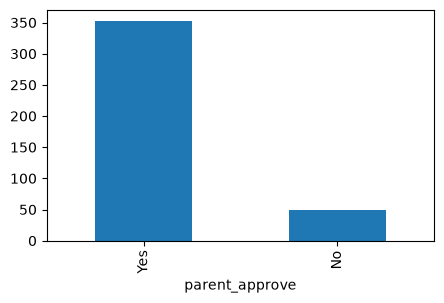

In [26]:
df.parent_approve.value_counts().plot(kind = "bar", figsize= (5,3))

<Axes: >

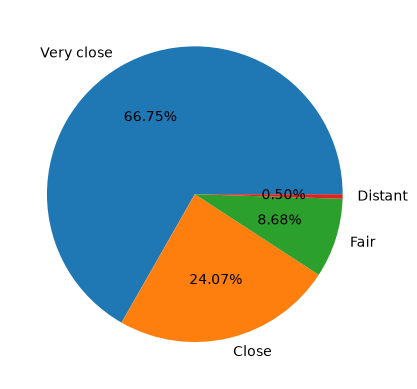

In [27]:
df.relation_parent.value_counts().plot(kind = "pie", autopct = "%1.2f%%" )

## Overall summary of the survey data " Univarient Description"

The dataset contains **406 student responses** across 17 variables, covering demographics, academic performance, finances, socialising/alcohol use, relationships, and parental attitudes.

### Key findings

* **Gender:** The sample is fairly balanced, with **53.5% male** and **46.5% female** respondents.
* **Academic background:** The average Grade 12/matric result was approximately **78%**. Among students with a 2023 university average recorded, the mean was about **66.3%**.
* **Field of study:** The sample is heavily concentrated in **Economic & Management Sciences (52.9%)**, followed by Science (14.0%), Arts & Social Sciences (11.8%), and Engineering (9.3%).
* **Year of study:** Most respondents were in their **1st or 2nd year** in 2023, accounting for 128 and 153 respondents respectively.
* **Finances:** The most common monthly allowance was **R4,001–R5,000 (42.4%)**, followed by R5,001–R6,000 (26.9%). About **11.6%** reported receiving a scholarship/bursary.
* **Studying outside class:** Most students reported additional study time, with **28.3% studying 8+ hours per week** and only 5% reporting no additional study.
* **Socialising:** The most common pattern was going out **only on weekends (28.0%)**, followed by going out once per week (26.7%) and twice per week (21.5%).
* **Alcohol consumption:** Alcohol use is relatively common. **27.5%** reported consuming 5–8 drinks on a typical night out, while **21.3% reported 8+ drinks**. Only 6.4% reported consuming no alcohol.
* **Alcohol-related academic disruption:** Although **53.1% said they missed no classes because of alcohol**, 18.6% missed one class, 15.6% missed two, and about **12.7% missed three or more classes** per week.
* **Academic failures:** **65.3% had failed no modules**, while 14.4% had failed one, 7.7% had failed two, and roughly 12.7% had failed three or more.
* **Relationships:** **40.7%** were currently in a romantic relationship.
* **Parents and alcohol:** A large majority (**87.8%**) said their parents approve of alcohol consumption.
* **Parent-child relationships:** Relationships with parents were generally strong: **66.7% described them as very close** and another 24.1% as close. Only 9.2% described the relationship as fair or distant.

### Overall interpretation

The survey portrays a predominantly **young university-student population with reasonably strong academic backgrounds and generally close parental relationships**. Socialising and alcohol consumption are widespread, with a substantial proportion reporting relatively high alcohol intake. However, most students report **no alcohol-related class absences and no failed modules**.

There is some indication of an **academic cost associated with alcohol-related behaviour**: students reporting more alcohol-related missed classes tended to have lower 2023 academic averages (approximately **67.4% among those missing no classes vs. 64.4% among those missing 4+ classes**). The relationship between number of drinks and academic performance is less straightforward, so the data should **not be interpreted as proving that alcohol causes lower grades**.

One important limitation is that some variables contain missing responses—particularly the 2023 academic average, which is unavailable for **86 respondents**, largely because first-year students were instructed to ignore that question. Therefore, analyses involving university academic performance should use the appropriate subset rather than all 406 respondents.


In [28]:
table = pd.crosstab(df.parent_approve,df.relation_parent)
table = table[["Distant","Fair","Close","Very close"]]
table

relation_parent,Distant,Fair,Close,Very close
parent_approve,,,,
No,1,9,18,20
Yes,1,25,79,248


<Axes: title={'center': 'Relationship between parents approval and parent-child relationship'}, xlabel='degree of parent-child relationship', ylabel='student-count'>

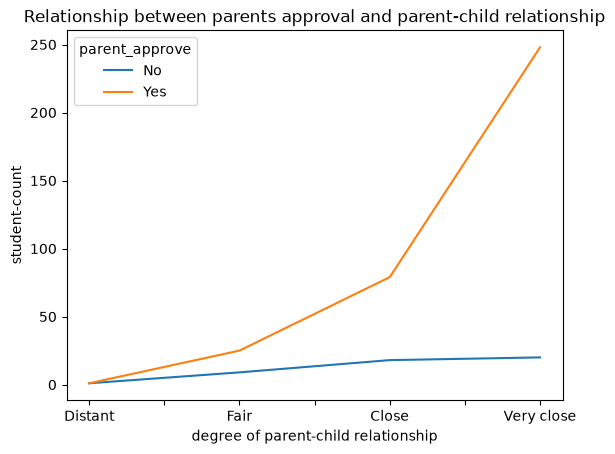

In [29]:
table.T.plot(
    kind = "line",
    title= "Relationship between parents approval and parent-child relationship",
    ylabel= "student-count",
    xlabel = "degree of parent-child relationship"
)

In [30]:
relation_grade = df.groupby("relation_parent")["unv_grade_2023"].aggregate(["min","max","mean"])
relation_grade = relation_grade.T[["Distant","Fair","Close","Very close"]]
relation_grade

relation_parent,Distant,Fair,Close,Very close
min,88.0,50.000000,50.000000,30.000000
max,89.0,85.000000,95.220000,92.000000
mean,88.5,66.258065,65.220769,66.527356


<Axes: ylabel='relation_parent'>

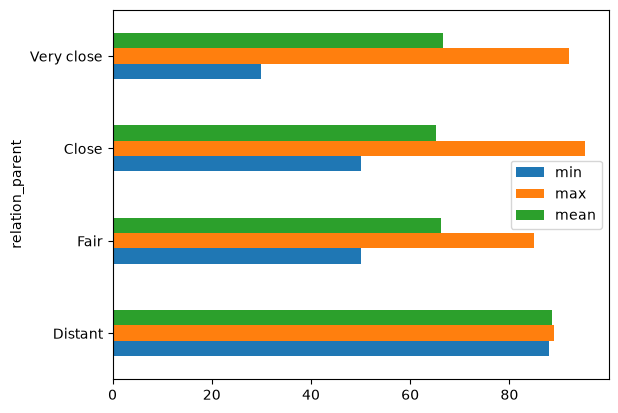

In [31]:
relation_grade.T.plot(kind = "barh")

The chart is a horizontal bar chart comparing **minimum, maximum, and mean** values across four parent-child relationship categories:

* **Very close:** min ≈ 30, mean ≈ 67, max ≈ 92.
* **Close:** min ≈ 50, mean ≈ 65, max ≈ 95.
* **Fair:** min ≈ 50, mean ≈ 66, max ≈ 85.
* **Distant:** min ≈ 88, mean ≈ 89, max ≈ 89.

The data suggest that the Distant group is associated with consistently high values, while the Very close, Close, and Fair groups show substantially more variability. However, this chart alone does not establish that parent-child relationship causes higher or lower values. To make a stronger prediction, we would need the underlying observations, sample sizes, and ideally statistical tests such as ANOVA or regression


<Axes: ylabel='faculty'>

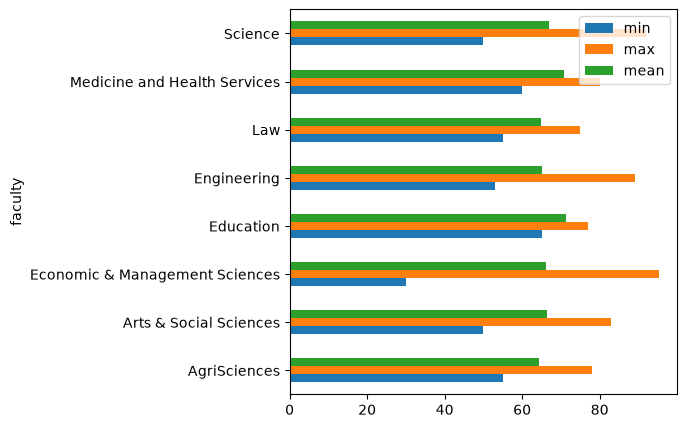

In [41]:
df.groupby("faculty")["unv_grade_2023"].aggregate(["min","max","mean"]).plot(kind = "barh", figsize= (5,5))

## Based on the pattern in the chart:

1. Education and Medicine & Health Services are likely to maintain relatively high average values compared with most other faculties.
2. Economic & Management Sciences may continue to show high-performing cases, because its maximum is very high (~95), but its low minimum suggests that outcomes can vary considerably.
3. Science is likely to have some of the highest individual values, given its maximum of about 95, but its minimum (~50) indicates substantial variation.
4. Education appears to be the most consistent high-performing faculty, with values concentrated between roughly 65 and 77.
5. AgriSciences may have comparatively lower average values, although its range is not as extreme as Economic & Management Sciences.

### Overall conclusion

The results indicate that faculty is associated with noticeable differences in the measured outcome. Medicine & Health Services and Education show the highest average performance, while Science and Economic & Management Sciences reach the highest maximum values. Economic & Management Sciences exhibits the greatest variability, whereas Education appears relatively consistent. These patterns suggest that faculty-specific factors may influence the outcome, but statistical testing would be required before concluding that the differences are significant.

<Axes: ylabel='scholarship'>

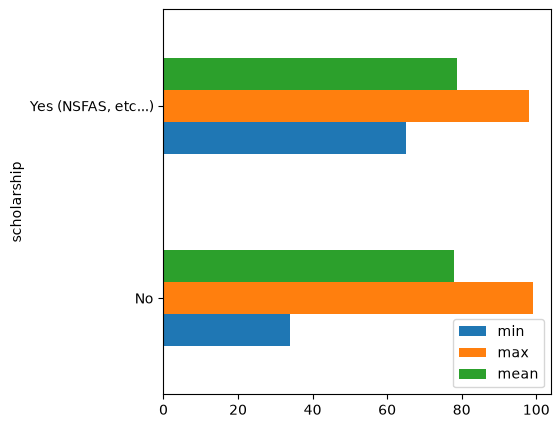

In [40]:
df.groupby("scholarship")["highschool_%"].aggregate(["min","max","mean"]).plot(kind = "barh", figsize= (5,5))

Highschool percentage has played little to none on scholarship given to students except the minimum percentage value obtained by scholarship students is higher.

<Axes: ylabel='scholarship'>

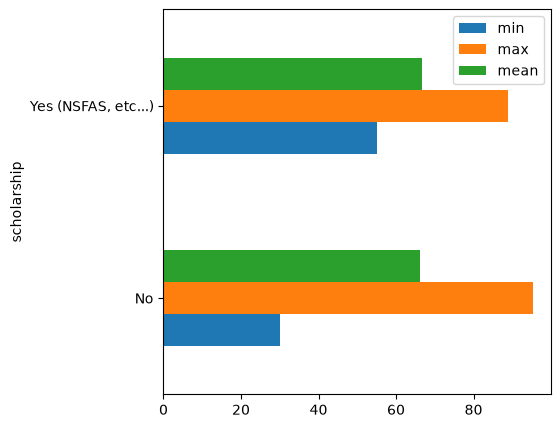

In [39]:
df.groupby("scholarship")["unv_grade_2023"].aggregate(["min","max","mean"]).plot(kind = "barh", figsize= (5,5))

Yearly average percentage has played little to none on scholarship given to students except the minimum value obtained by scholarship students is higher.

In [35]:
pd.crosstab(df.gender,df.scholarship)

scholarship,No,"Yes (NSFAS, etc...)"
gender,,
Female,165,19
Male,187,27


<Axes: >

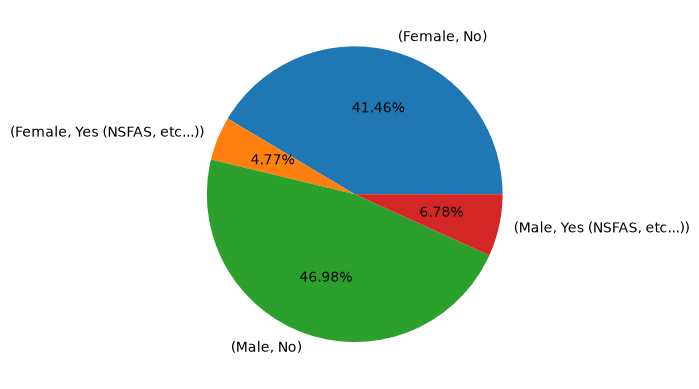

In [36]:
df.groupby("gender")["scholarship"].value_counts().plot(kind = "pie", autopct = "%1.2f%%")

Male students have 3 % higher chance of getting scholarship.

<Axes: ylabel='study_year'>

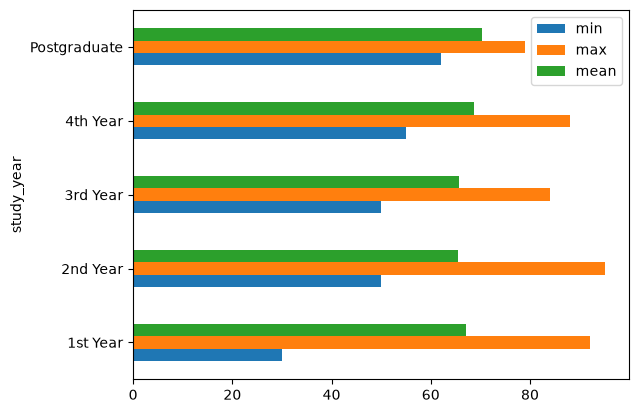

In [37]:
df.groupby("study_year")["unv_grade_2023"].aggregate(["min","max","mean"]).plot(kind = "barh")

The mean grade and maximum grade of student across has less variable change where as the minimum value of grade is lower for first year than other students. 